In [1]:
##### Importacion de modulos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import MultipleLocator
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import os

##### Cambiando directorio
print(os.getcwd())
if os.getcwd().split('\\')[-1] != 'PostSQL':
    os.chdir('./Datos/PostSQL')


c:\Users\JP\Documents\DSProyectos\4_DemandaForecasting


In [2]:
##### Leyendo y Cargando datos
df = pd.read_csv('ventas_productos.csv')
# df.info()


##### Fechas y Datetime
#### Transformanco fechas a DateTime
df['fecha'] = pd.to_datetime(
    df['fecha'],
    format='%d/%m/%Y',
    dayfirst=True,
    errors='coerce'
)
#### Verificando que todos los datos son del anio 2024
print(df['fecha'].dt.year.unique().tolist())
#### Creando columnas: dia, semana, mes
df['dia'] = df['fecha'].dt.day
df['dia_semana'] = df['fecha'].dt.weekday + 1
df['semana'] = df['fecha'].dt.isocalendar().week
df['mes'] = df['fecha'].dt.month
#### Ordenando datos por fecha
df = df.drop(columns='fecha')\
    .sort_values(by=['mes','dia'], ascending=[True, True])
#### Rango de fechas: 31/1/24 - 30/12/24
    # 31/1/24 se traslada a la 5ta semana del anio 2024
    # PERO 30/12/25 se traslada a la 1ra semana del anio 2025
        # Ende: Borrar
df = df[~((df['dia']==30) & (df['mes']==12))]
#### MEs de Enero
    # Los datos del mes de enero estan incompletos
    # Se van a borrar
df = df.drop(df[df['mes']==1].index)
#### Reseteo de los indices
df = df.reset_index(drop=True)


##### Creando categoria de ingresos
df['ingreso'] = df['cantidad'] * df['precio']


##### Stock
    # El valor de 'stock' es un valor para todo el anio
        # Entonces para diferentes granularidades se tiene
                # que hacer una division igual entre ellas
# len(df['stock'].unique())
# df['stock'] = (df['stock']/52).astype(int)


#### Resumen
df.info()


[2024]
<class 'pandas.DataFrame'>
RangeIndex: 2986 entries, 0 to 2985
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_venta    2986 non-null   int64 
 1   cliente_id  2986 non-null   int64 
 2   cantidad    2986 non-null   int64 
 3   stock       2986 non-null   int64 
 4   nombre      2986 non-null   str   
 5   categoria   2986 non-null   str   
 6   precio      2986 non-null   int64 
 7   dia         2986 non-null   int32 
 8   dia_semana  2986 non-null   int32 
 9   semana      2986 non-null   UInt32
 10  mes         2986 non-null   int32 
 11  ingreso     2986 non-null   int64 
dtypes: UInt32(1), int32(3), int64(6), str(2)
memory usage: 236.3 KB


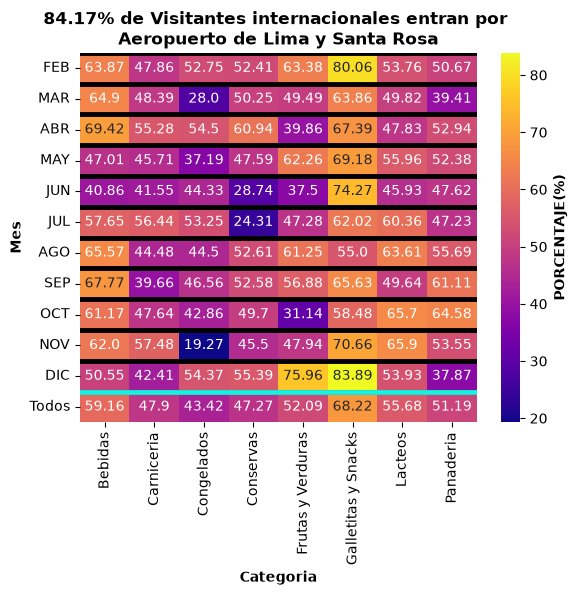

In [ ]:
##### Productos perdidos: Categorias
#### Seleccionando datos
df_mc=df\
    .groupby(by=['mes', 'categoria'], as_index=False)\
    .agg(
        cantidad_vendida = pd.NamedAgg(
            column='cantidad', aggfunc= lambda series: series.sum()
        ),
        stock_mensual = pd.NamedAgg(
            column='stock', aggfunc= lambda series: int(series.mean()/12)
        )
    )
#### Metrica PPP
df_mc['PPP'] = (
    (
        (df_mc['stock_mensual'] - df_mc['cantidad_vendida'])/df_mc['stock_mensual']
    ) * 100
).round(2)
#### Filtrando columnas
df_mc = df_mc.drop(columns=['cantidad_vendida', 'stock_mensual'])



##### Creando columna todos
#### Creando promedio de todos los meses
df_todos = df_mc\
    .groupby(by='categoria', as_index=False)\
    .agg(
        PPP = pd.NamedAgg(
            column='PPP', aggfunc= lambda series: series.mean().round(2)
        )
    )
#### Agregando el mes '13' = promedio de todos los meses
df_todos['mes'] = [13]*df_todos.shape[0]
#### Concatenacion
df_mcp = pd.concat([df_mc, df_todos], axis=0, ignore_index=True)


##### Creando heatmap
#### Colores
vmin, vmax = 0, 100
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.plasma  # perceptually uniform, high contrast


#### Pivot table
heatmap_data = df_mcp\
    .pivot_table(
        index='mes',
        columns='categoria',
        values='PPP'
    )

#### grafica
ax = sns.heatmap(
    heatmap_data, 
    annot=True, 
    cmap=cmap,
    fmt='0',
    linewidths=0,
    linecolor='black',
    cbar=True,
)

#### Agregando lineas horizontales
n_rows = df_mcp['mes'].unique().shape[0]
for y in range(n_rows):
    ax.axhline(y, color="black", lw=3.5)  # Adjust color and thickness
    if y == (n_rows-1):
        ax.axhline(y, color="#18f1dfff", lw=3.5)


#### COnfiguraciones de heatmap
meses = ['FEB', 'MAR', 'ABR', 'MAY', 'JUN',\
         'JUL', 'AGO', 'SEP', 'OCT', 'NOV', 'DIC', 'Todos']
ax.set_title('84.17% de Visitantes internacionales entran por \nAeropuerto de Lima y Santa Rosa', fontweight='bold')
ax.set_yticklabels(meses, rotation=0)
ax.set_ylabel('Mes', fontweight='bold')
ax.set_xlabel('Categoria', fontweight='bold')
ax.collections[0].colorbar.set_label('Porcetaje (%)', fontweight='bold')



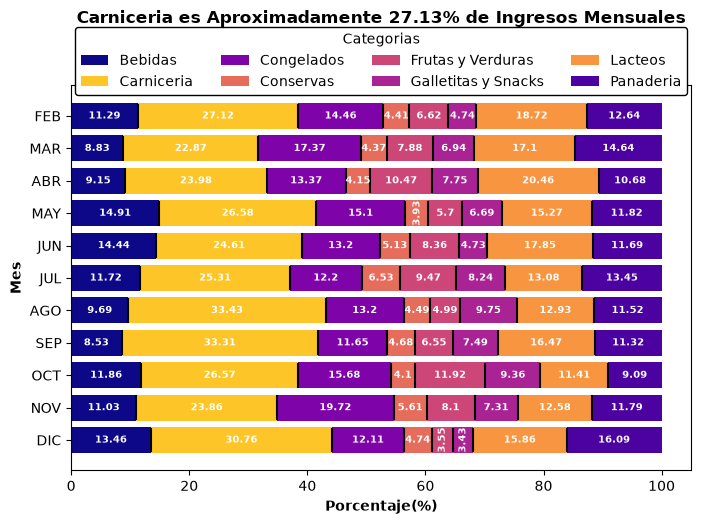

In [ ]:
###### Categoria vs Ingreso
    # Ver cual % del ingreso mensual es contribuido por cada categoria
##### Seleccion de datos
df_mc = df\
    .groupby(by=['mes', 'categoria'], as_index=False)\
    .agg(
        ingreso_mensual = pd.NamedAgg(
            column='ingreso', aggfunc= lambda series: series.sum()
        )
    )

##### Haciendo porcentaje mensual de cada categoria
df_mc['porcentaje'] = (
    (
        df_mc['ingreso_mensual'] / \
        df_mc.groupby(by='mes')['ingreso_mensual'].transform(
            lambda series: series.sum()
        )
    ) * 100
).round(2)

##### Creando visual
#### Config inicial
ANCH = 8
ALT = 5
meses = ['FEB', 'MAR', 'ABR', 'MAY', 'JUN',\
         'JUL', 'AGO', 'SEP', 'OCT', 'NOV', 'DIC']
categorias = df_mc['categoria'].unique()
y_pos = np.arange(len(meses))
left_accum = np.zeros(len(meses))

#### Colores
vmin, vmax = 0, 100
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.plasma  # perceptually uniform, high contrast

fig, ax = plt.subplots(figsize=(ANCH,ALT))
#### Figura
for i, cat in enumerate(categorias):
    ### Creando datos de esta iteracion
    valores = df_mc[df_mc['categoria']==cat]['porcentaje'].values.tolist()
    ### Creando las barras
    barras = ax.barh(
        y_pos,
        valores,
        left = left_accum,
        color = cmap(norm(i*(100/len(categorias)))) if not i%2 \
            else cmap(norm(100 - (i*(100/len(categorias))))),
        label = cat
    )
    ### Agregando barras de separacion
    altura_barra = 0.7  # ancho de barra por defecto en barh()
    for i in range(len(meses)):
        ax.plot(
            # Hacer linea desde (x1,y1) hacia (x2,y2)
            [left_accum[i], left_accum[i]], #[x1, x2]
            [y_pos[i] - altura_barra/2, y_pos[i] + altura_barra/2], #[y1,y2]
            color='black', linewidth=1.5
        )
    ### Creando el texto
    for bar, valor in zip(barras, valores):
        x_center = bar.get_x() + bar.get_width() / 2
        y_center = bar.get_y() + bar.get_height() / 2
        ax.text(
            x_center, y_center,
            f"{valor}",  # Texto a mostrar
            ha="center", va="center",
            color="white", fontsize=7, fontweight="bold",
            rotation=90 if valor < 4 else 0
        )
    left_accum += valores
#### Configs finales
ax.invert_yaxis()
ax.set_yticks(y_pos)
ax.set_yticklabels(meses)
ax.set_ylabel('Mes', fontweight='bold')
ax.set_xlabel('Porcentaje(%)', fontweight='bold')
promedio = df_mc[df_mc['categoria'] == 'Carniceria']['porcentaje'].mean().round(2)
ax.set_title(f'Carniceria es Aproximadamente {promedio}% de Ingresos Mensuales',fontweight='bold', pad = 45)
ax.legend(
    ncols=int(len(categorias)/2), 
    loc='upper center', 
    bbox_to_anchor=(0.5,1.17), 
    title='Categorias',
    edgecolor='black',
    framealpha=1.0
)

plt.show()



Text(0.5, 0.98, '4 Meses del Anio con Altos ARPUs')

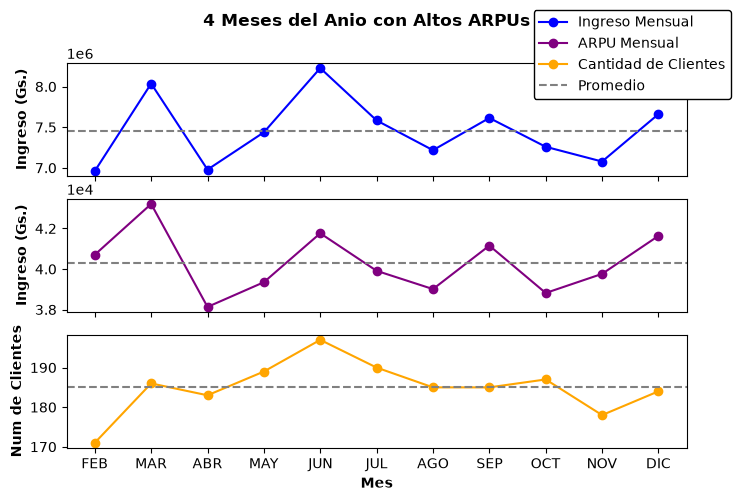

In [6]:
###### ARPU Box plots
##### Seleccionando datos
#### Datos genera
df_mcl=df\
    .groupby(by=['mes','cliente_id'], as_index=False)\
    .agg(
        ingreso_mensual_por_cliente = pd.NamedAgg(
            column='ingreso', aggfunc= lambda series: series.sum()
        )
    )
# display(df_mcl)

#### Datos arpu
df_arpu = df_mcl\
    .groupby(by='mes', as_index=False)\
    .agg(
        ingreso_mensual = pd.NamedAgg(
            column='ingreso_mensual_por_cliente', aggfunc=lambda series: series.sum()
        ),
        cantidad_clientes = pd.NamedAgg(
            column='cliente_id', aggfunc=lambda series: series.count()
        ),
        arpu_mensual = pd.NamedAgg(
            column='ingreso_mensual_por_cliente', aggfunc= lambda series: series.mean().round(2)
        ),
    )

# display(df_arpu)

##### Grafica
#### Config inicial
ANCH = 8
ALT = 5
fig, axs = plt.subplots(ncols=1, nrows=3, figsize=(ANCH, ALT), sharex=True)
meses = ['FEB', 'MAR', 'ABR', 'MAY', 'JUN',\
         'JUL', 'AGO', 'SEP', 'OCT', 'NOV', 'DIC']
#### Creando la grafica
### Ingreso Mensual
axs[0].plot(
    range(len(meses)),
    df_arpu['ingreso_mensual'],
    label='Ingreso Mensual',
    marker='o',
    color='blue'
)
### ARPU Mensual
axs[1].plot(
    range(len(meses)),
    df_arpu['arpu_mensual'],
    label='ARPU Mensual',
    marker='o',
    color='purple'
)
### Cantidad de Clientes
axs[2].plot(
    range(len(meses)),
    df_arpu['cantidad_clientes'],
    label='Cantidad de Clientes',
    marker='o',
    color='orange'
)
#### Agregado promedios
axs[0].axhline(
    df_arpu['ingreso_mensual'].mean(),
    color = 'grey',
    linestyle='--', 
    linewidth=1.5, 
)
axs[1].axhline(
    df_arpu['arpu_mensual'].mean(),
    color = 'grey',
    linestyle='--', 
    linewidth=1.5, 
)
axs[2].axhline(
    df_arpu['cantidad_clientes'].mean(),
    color = 'grey',
    linestyle='--', 
    linewidth=1.5, 
    label='Promedio'
)
#### Configs finales
### ax2
axs[2].set_xticks(range(len(meses)))
axs[2].set_xticklabels(meses)
axs[2].set_xlabel('Mes', fontweight='bold')
axs[2].set_ylabel('Num de Clientes', fontweight='bold')
### ax1
axs[1].set_ylabel('Ingreso (Gs.)', fontweight='bold')
axs[1].ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
### ax0
axs[0].set_ylabel('Ingreso (Gs.)', fontweight='bold')
fig.legend(
    loc='upper left', 
    bbox_to_anchor=(0.7,1.0), 
    framealpha=1.0,
    edgecolor='black'
)
fig.suptitle('4 Meses del Anio con Altos ARPUs', fontweight='bold')
